# 1. Environment Setup & Dataset Downloading
This section authenticates with Kaggle using the API token, installs necessary packages, and downloads the **Chest X-Ray Pneumonia Dataset**.

In [7]:
import os

# Set Kaggle API Token for authentication
os.environ['KAGGLE_API_TOKEN'] = "KGAT_b8682b27226ea9a06f4e838b08d17728"

# Upgrade Kaggle CLI to ensure API compatibility
!pip install --upgrade kaggle -q

# Download and extract the Pneumonia dataset
print("Downloading dataset...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

print("Extracting files...")
!unzip -q chest-xray-pneumonia.zip -d ./data

print("Dataset downloaded and extracted successfully!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracting files...
replace ./data/chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dataset downloaded and extracted successfully!


# 2. Data Preprocessing & Loading Pipeline
Configuring image transformations (resizing to 224x224, data augmentation, and ImageNet normalization) and instantiating PyTorch DataLoaders.

In [8]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define dataset directory paths
data_dir = './data/chest_xray'
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')
test_dir = os.path.join(data_dir, 'test')

# Define image transformations for feature normalization and augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Initialize datasets using PyTorch ImageFolder
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, data_transforms['val'])
}

# Create DataLoaders for batching and shuffling
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False, num_workers=2)
}

# Print dataset summary metrics
print(f"Training samples: {len(image_datasets['train'])}")
print(f"Validation samples: {len(image_datasets['val'])}")
print(f"Detected classes: {image_datasets['train'].classes}")

Training samples: 5216
Validation samples: 16
Detected classes: ['NORMAL', 'PNEUMONIA']


# 3. Model Architecture (ResNet18 Transfer Learning)
Loading a pre-trained ResNet18 model, modifying the final fully connected layer for binary classification (NORMAL vs PNEUMONIA), and moving the model to GPU memory.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Set device to GPU if available, otherwise CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Load pre-trained ResNet18 model
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Modify final linear layer for binary classification (2 output features)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# Transfer model to GPU
model = model.to(device)

# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model successfully loaded and running on: {device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


Model successfully loaded and running on: cuda:0


# 4. Model Training and Validation
Executing the training loop over 5 epochs with real-time performance tracking for training/validation loss and accuracy, while preserving the best-performing model weights.

In [10]:
import copy
import time

def train_model(model, criterion, optimizer, num_epochs=5):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data batches
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero parameter gradients
                optimizer.zero_grad()

                # Track history only during training
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass + optimization in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Track batch metrics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the best model weights based on validation accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Validation Accuracy: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model

# Train the ResNet18 model
trained_model = train_model(model, criterion, optimizer, num_epochs=5)

Epoch 1/5
----------
Train Loss: 0.1092 Acc: 0.9574
Val Loss: 1.5870 Acc: 0.5625

Epoch 2/5
----------
Train Loss: 0.0772 Acc: 0.9734
Val Loss: 1.8263 Acc: 0.6250

Epoch 3/5
----------
Train Loss: 0.0625 Acc: 0.9797
Val Loss: 0.1430 Acc: 1.0000

Epoch 4/5
----------
Train Loss: 0.0555 Acc: 0.9778
Val Loss: 0.2261 Acc: 0.9375

Epoch 5/5
----------
Train Loss: 0.0428 Acc: 0.9837
Val Loss: 0.0401 Acc: 1.0000

Training complete in 6m 41s
Best Validation Accuracy: 1.0000


# 5. Model Evaluation & Sample Visualizations
De-normalizing validation set images and running qualitative inference to check ground truth vs. predicted labels (Green = Correct, Red = Incorrect).

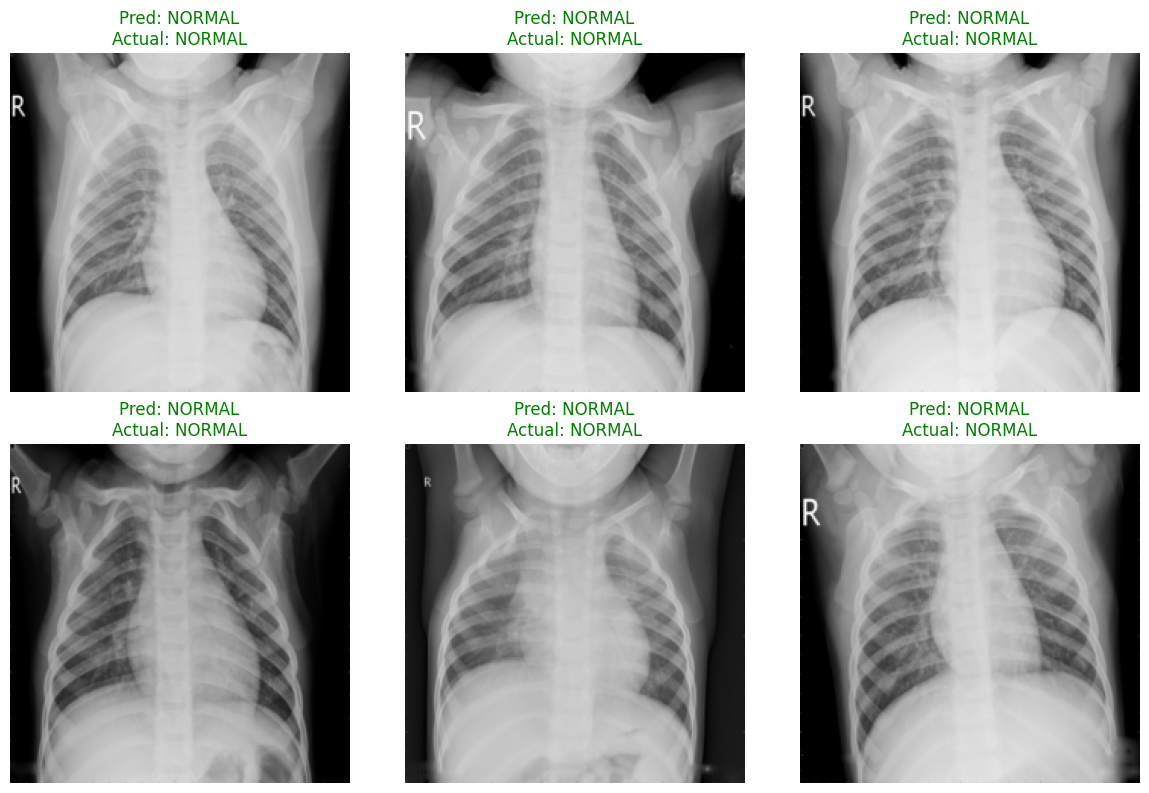

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function to un-normalize and render images
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')

# Display predictions on validation samples
def visualize_predictions(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(12, 8))

    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 3, 3, images_so_far)

                pred_class = image_datasets['val'].classes[preds[j]]
                actual_class = image_datasets['val'].classes[labels[j]]
                title_color = 'green' if preds[j] == labels[j] else 'red'

                imshow(inputs.cpu().data[j])
                ax.set_title(f"Pred: {pred_class}\nActual: {actual_class}", color=title_color)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    plt.tight_layout()
                    plt.show()
                    return
        model.train(mode=was_training)

visualize_predictions(trained_model, num_images=6)

# 6. Model Interpretability via Grad-CAM
Generating heatmaps from the final convolutional block (`model.layer4[-1]`) to pinpoint pathological attention regions during diagnostic inference.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


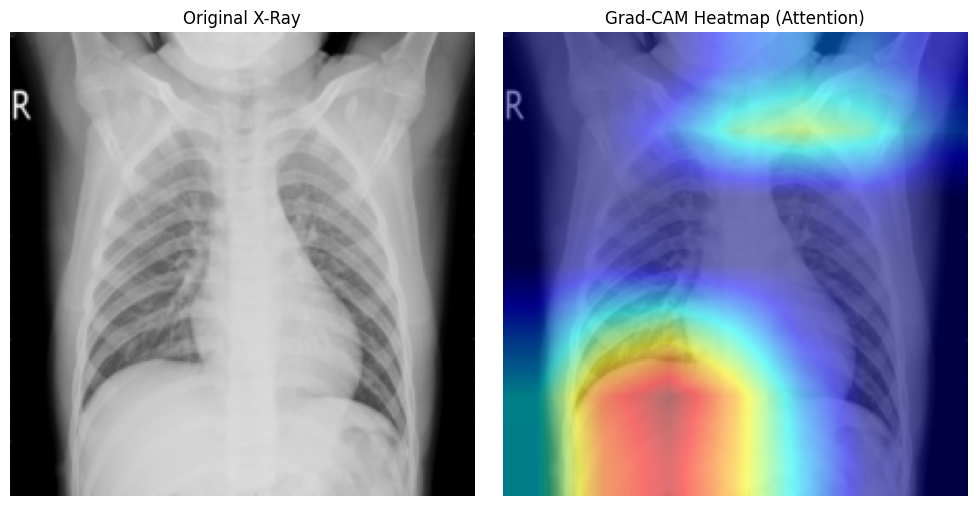

In [12]:
!pip install grad-cam -q

import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Target final convolutional layer of ResNet18
target_layers = [trained_model.layer4[-1]]

# Initialize GradCAM instance
cam = GradCAM(model=trained_model, target_layers=target_layers)

# Fetch sample validation batch
inputs, labels = next(iter(dataloaders['val']))
input_tensor = inputs[0].unsqueeze(0).to(device)

# Compute Grad-CAM mask
targets = [ClassifierOutputTarget(labels[0].item())]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# Process base image for display
rgb_img = inputs[0].numpy().transpose((1, 2, 0))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
rgb_img = std * rgb_img + mean
rgb_img = np.clip(rgb_img, 0, 1)

# Overlay heatmap onto base X-ray image
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(rgb_img)
axes[0].set_title("Original X-Ray")
axes[0].axis('off')

axes[1].imshow(visualization)
axes[1].set_title("Grad-CAM Heatmap (Attention)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 7. Model Serialization
Exporting the final trained weights for deployment and downstream integration.

In [13]:
# Save model state dictionary
torch.save(trained_model.state_dict(), 'pneumonia_resnet18_model.pth')
print("Model weights successfully saved as pneumonia_resnet18_model.pth!")

Model weights successfully saved as pneumonia_resnet18_model.pth!
